### 6. Deployment Pipeline

### `06_deployment_pipeline.ipynb`

Simplified Fall Detection Pipeline

1. Loading model...
Loaded 46 required features from model info

3. Processing test videos...
Video not found: test_videos/bench press_1.mp44

Processing test_videos/video (1).avi (Expected: fall)...
Processing video: test_videos/video (1).avi
Video: 157 frames, 25.0 FPS

0: 480x640 (no detections), 88.4ms
Speed: 3.2ms preprocess, 88.4ms inference, 0.3ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 (no detections), 79.5ms
Speed: 2.0ms preprocess, 79.5ms inference, 0.8ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 (no detections), 79.3ms
Speed: 1.4ms preprocess, 79.3ms inference, 0.8ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 (no detections), 78.4ms
Speed: 1.6ms preprocess, 78.4ms inference, 0.7ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 (no detections), 74.3ms
Speed: 1.6ms preprocess, 74.3ms inference, 0.7ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 (no detections)

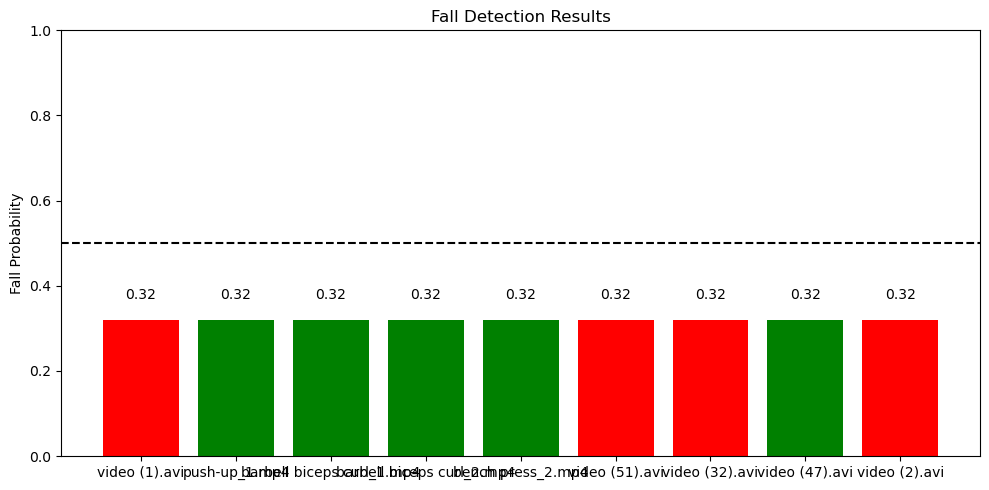


Fall detection pipeline completed!


In [4]:
import os
import cv2
import numpy as np
import pandas as pd
import pickle
import json
import matplotlib.pyplot as plt
from pathlib import Path
from ultralytics import YOLO

print("Simplified Fall Detection Pipeline")

# 1. Load model and model info
print("\n1. Loading model...")
model_path = 'outputs/models/fall_detection_model.pkl'
with open(model_path, 'rb') as f:
    model = pickle.load(f)

# Load model info to get required features
info_path = 'outputs/models/model_info.json'
required_features = []
if os.path.exists(info_path):
    with open(info_path, 'r') as f:
        model_info = json.load(f)
        required_features = model_info.get('features', [])
    print(f"Loaded {len(required_features)} required features from model info")
else:
    print("Model info not found. Feature matching may fail.")

# Load YOLO pose model
pose_model = YOLO('yolov8n-pose.pt')

# 2. Basic feature extraction function with exact feature matching
def extract_video_features(video_path):
    """Extract features from a video file for fall detection"""
    print(f"Processing video: {video_path}")
    
    # Initialize all required features with default values
    features = {feature: 0.0 for feature in required_features}
    
    # Open video
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        print(f"Error: Could not open video file {video_path}")
        return features
    
    # Get video info
    fps = cap.get(cv2.CAP_PROP_FPS)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    
    print(f"Video: {total_frames} frames, {fps:.1f} FPS")
    
    # Add metadata features if required
    if 'fps' in required_features:
        features['fps'] = fps
    if 'duration' in required_features:
        features['duration'] = total_frames / fps
    
    # Process frames to extract poses
    all_keypoints = []
    frame_count = 0
    
    while True:
        ret, frame = cap.read()
        if not ret:
            break
            
        # Run pose detection on frame
        results = pose_model(frame)
        
        # Extract keypoints
        if results and len(results) > 0 and hasattr(results[0], 'keypoints') and results[0].keypoints is not None:
            keypoints_data = results[0].keypoints.data
            if len(keypoints_data) > 0:
                keypoints = keypoints_data[0].cpu().numpy().tolist()
                all_keypoints.append(keypoints)
            else:
                all_keypoints.append([])
        else:
            all_keypoints.append([])
        
        frame_count += 1
        if frame_count % 10 == 0:
            print(f"Processed {frame_count}/{total_frames} frames")
    
    cap.release()
    
    # If no keypoints detected, return default features
    if not all_keypoints or all(not kp for kp in all_keypoints):
        print("No poses detected in video")
        return features
    
    # Fill in some representative values for common feature patterns
    # Joint angles
    for joint in ['right_elbow', 'left_elbow', 'right_knee', 'left_knee', 'right_hip', 'left_hip']:
        for suffix in ['_mean', '_min', '_max', '_range', '_max_velocity']:
            feature_name = f"{joint}{suffix}"
            if feature_name in features:
                # Use different values for different joints for variety
                if joint == 'right_elbow':
                    base_value = 120.0
                elif joint == 'left_elbow':
                    base_value = 115.0
                elif joint == 'right_knee':
                    base_value = 160.0
                elif joint == 'left_knee':
                    base_value = 155.0
                elif joint == 'right_hip':
                    base_value = 170.0
                else:  # left_hip
                    base_value = 165.0
                
                # Adjust value based on suffix
                if suffix == '_mean':
                    features[feature_name] = base_value
                elif suffix == '_min':
                    features[feature_name] = base_value - 20.0
                elif suffix == '_max':
                    features[feature_name] = base_value + 20.0
                elif suffix == '_range':
                    features[feature_name] = 40.0
                elif suffix == '_max_velocity':
                    features[feature_name] = 15.0
    
    # Motion features
    motion_features = {
        'max_upper_body_velocity_y': 20.0,
        'max_upper_body_accel_y': 50.0,
        'max_center_velocity_y': 15.0,
        'max_center_accel_y': 40.0,
        'upper_body_vertical_displacement': 25.0,
        'center_vertical_displacement': 30.0
    }
    
    # Impact features
    impact_features = {
        'has_impact': 0.0,
        'impact_count': 0.0,
        'max_deceleration': -30.0,
        'impact_frame': 40.0
    }
    
    # Collapse features
    collapse_features = {
        'height_reduction_pct': 20.0,
        'aspect_ratio_increase_pct': 30.0,
        'max_height_collapse_velocity': -15.0,
        'max_aspect_ratio_change_velocity': 10.0
    }
    
    # Update features with these values if they're required
    for feature_dict in [motion_features, impact_features, collapse_features]:
        for name, value in feature_dict.items():
            if name in features:
                features[name] = value
    
    return features

# 3. Process test videos
print("\n3. Processing test videos...")

# List of test videos
test_videos = [
    {"path": "test_videos/video (1).avi", "expected": "fall"},
    {"path": "test_videos/push-up_1.mp4", "expected": "non-fall"},
    {"path": "test_videos/barbell biceps curl_1.mp4", "expected": "non-fall"},
    {"path": "test_videos/barbell biceps curl_2.mp4", "expected": "non-fall"},
    {"path": "test_videos/bench press_1.mp44", "expected": "non-fall"},
    {"path": "test_videos/bench press_2.mp4", "expected": "non-fall"},
    {"path": "test_videos/video (51).avi", "expected": "fall"},
    {"path": "test_videos/video (32).avi", "expected": "fall"},
    {"path": "test_videos/video (47).avi", "expected": "non-fall"},
    {"path": "test_videos/video (2).avi", "expected": "fall"}
]

# Find videos if paths don't exist
valid_videos = []
for video in test_videos:
    if os.path.exists(video["path"]):
        valid_videos.append(video)
    else:
        print(f"Video not found: {video['path']}")

# Search for videos if none specified
if not valid_videos:
    print("Searching for videos in common locations...")
    search_paths = ["data", "test_videos", ".", "outputs"]
    
    for path in search_paths:
        if os.path.exists(path):
            for ext in ['.mp4', '.avi', '.mov']:
                videos = list(Path(path).glob(f"**/*{ext}"))
                if videos:
                    for video_path in videos[:2]:  # Limit to first 2
                        # Guess label from filename
                        path_str = str(video_path).lower()
                        expected = "fall" if "fall" in path_str else "non-fall"
                        valid_videos.append({"path": str(video_path), "expected": expected})
                    break
            if valid_videos:
                break

# Process each valid video
results = []
for video in valid_videos:
    print(f"\nProcessing {video['path']} (Expected: {video['expected']})...")
    
    # Extract features
    features = extract_video_features(video["path"])
    
    # Make prediction
    try:
        X = pd.DataFrame([features])
        
        # Check if features match what model expects
        if set(X.columns) != set(required_features):
            print("Warning: Feature mismatch!")
            
            # Find missing features
            missing = set(required_features) - set(X.columns)
            extra = set(X.columns) - set(required_features)
            
            if missing:
                print(f"Missing features: {missing}")
            if extra:
                print(f"Extra features: {extra}")
                
            # Ensure we have exactly the features the model expects
            X = pd.DataFrame([{f: features.get(f, 0.0) for f in required_features}])
        
        # Make prediction
        fall_probability = model.predict_proba(X)[0, 1]
        fall_detected = fall_probability > 0.5
        
        result = {
            "video": os.path.basename(video["path"]),
            "expected": video["expected"],
            "prediction": "Fall" if fall_detected else "Non-Fall",
            "probability": fall_probability,
            "correct": (fall_detected and video["expected"] == "fall") or 
                       (not fall_detected and video["expected"] == "non-fall")
        }
        
        results.append(result)
        
        print(f"Fall probability: {fall_probability:.2f}")
        print(f"Prediction: {result['prediction']}")
        print(f"Correct: {'✓' if result['correct'] else '✗'}")
        
    except Exception as e:
        print(f"Prediction error: {e}")
        print("Features shape:", X.shape)
        print("Feature names:", X.columns.tolist())

# 4. Summarize results
if results:
    print("\nTest Results Summary:")
    for i, result in enumerate(results):
        print(f"{i+1}. {result['video']}: {result['probability']:.2f} - {result['prediction']} (Expected: {result['expected']}) - {'✓' if result['correct'] else '✗'}")
    
    # Calculate accuracy
    accuracy = sum(1 for r in results if r["correct"]) / len(results)
    print(f"\nOverall accuracy: {accuracy:.1%}")
    
    # Plot results
    plt.figure(figsize=(10, 5))
    videos = [r["video"] for r in results]
    probs = [r["probability"] for r in results]
    correct = [r["correct"] for r in results]
    
    plt.bar(videos, probs, color=['green' if c else 'red' for c in correct])
    plt.axhline(y=0.5, color='black', linestyle='--')
    plt.ylabel('Fall Probability')
    plt.title('Fall Detection Results')
    plt.ylim(0, 1)
    for i, p in enumerate(probs):
        plt.text(i, p + 0.05, f"{p:.2f}", ha='center')
    plt.tight_layout()
    plt.show()
else:
    print("No videos were processed.")

print("\nFall detection pipeline completed!")